=== MODEL COMPARISON AT 3.0C ===

Simulating SPM...
  Solve time: 0.301 seconds
  Capacity: 0.676 Ah

Simulating SPMe...
  Solve time: 0.432 seconds
  Capacity: 0.675 Ah

Simulating DFN...
  Solve time: 0.600 seconds
  Capacity: 0.675 Ah


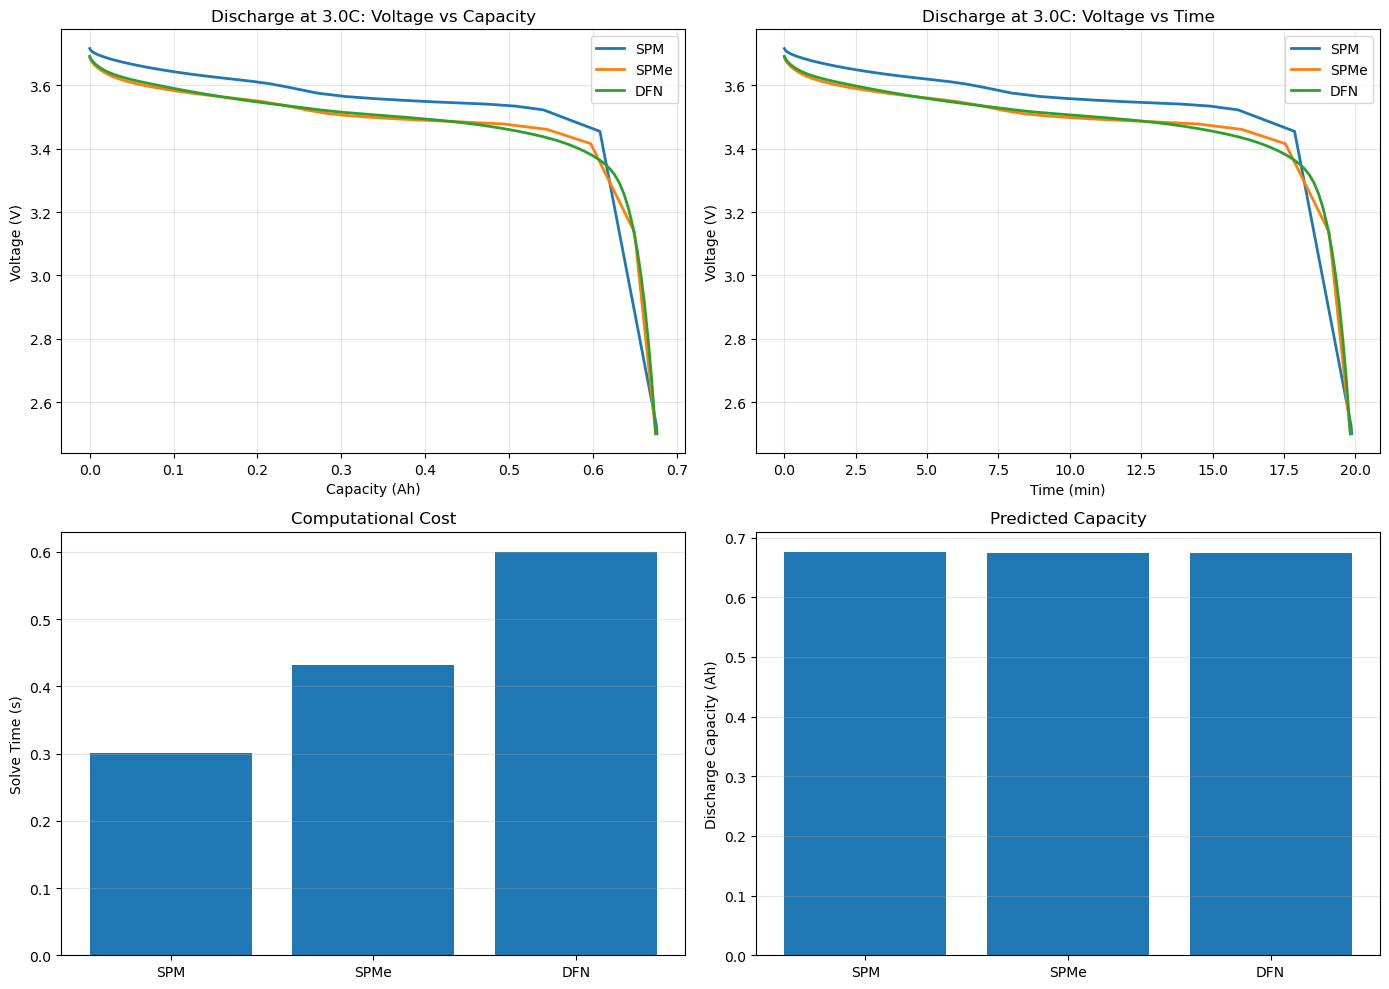


=== KEY INSIGHTS ===
At 3.0C discharge:
  SPM capacity: 0.676 Ah
  SPMe capacity: 0.675 Ah
  DFN capacity: 0.675 Ah

SPM vs DFN difference: 1.5 mAh
Speedup (DFN/SPM): 2.0x

✓ Model comparison complete!


In [1]:
# 11_model_comparison.py
"""
Compare SPM to SPMe and DFN
When does SPM break down?
"""

import pybamm
import matplotlib.pyplot as plt
import time as timer

# Models to compare
models = {
    'SPM': pybamm.lithium_ion.SPM(),
    'SPMe': pybamm.lithium_ion.SPMe(),
    'DFN': pybamm.lithium_ion.DFN(),
}

C_rate = 3.0  # High C-rate to show differences

print(f"=== MODEL COMPARISON AT {C_rate}C ===")

results = {}
solve_times = {}

for model_name, model in models.items():
    print(f"\nSimulating {model_name}...")
    
    experiment = pybamm.Experiment([f"Discharge at {C_rate}C until 2.5V"])
    sim = pybamm.Simulation(model, experiment=experiment)
    
    # Time the solve
    start = timer.time()
    solution = sim.solve()
    solve_time = timer.time() - start
    
    results[model_name] = solution
    solve_times[model_name] = solve_time
    
    print(f"  Solve time: {solve_time:.3f} seconds")
    print(f"  Capacity: {solution['Discharge capacity [A.h]'].entries[-1]:.3f} Ah")

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for model_name, solution in results.items():
    capacity = solution["Discharge capacity [A.h]"].entries
    voltage = solution["Terminal voltage [V]"].entries
    time = solution["Time [min]"].entries
    
    # Voltage vs capacity
    axes[0,0].plot(capacity, voltage, linewidth=2, label=model_name)
    
    # Voltage vs time
    axes[0,1].plot(time, voltage, linewidth=2, label=model_name)

axes[0,0].set_xlabel("Capacity (Ah)")
axes[0,0].set_ylabel("Voltage (V)")
axes[0,0].set_title(f"Discharge at {C_rate}C: Voltage vs Capacity")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

axes[0,1].set_xlabel("Time (min)")
axes[0,1].set_ylabel("Voltage (V)")
axes[0,1].set_title(f"Discharge at {C_rate}C: Voltage vs Time")
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Computational cost
model_names = list(solve_times.keys())
times = list(solve_times.values())

axes[1,0].bar(model_names, times)
axes[1,0].set_ylabel("Solve Time (s)")
axes[1,0].set_title("Computational Cost")
axes[1,0].grid(True, alpha=0.3, axis='y')

# Capacity comparison
capacities = [results[m]['Discharge capacity [A.h]'].entries[-1] for m in model_names]
axes[1,1].bar(model_names, capacities)
axes[1,1].set_ylabel("Discharge Capacity (Ah)")
axes[1,1].set_title("Predicted Capacity")
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()

# Key insights
print("\n=== KEY INSIGHTS ===")
print(f"At {C_rate}C discharge:")
print(f"  SPM capacity: {results['SPM']['Discharge capacity [A.h]'].entries[-1]:.3f} Ah")
print(f"  SPMe capacity: {results['SPMe']['Discharge capacity [A.h]'].entries[-1]:.3f} Ah")
print(f"  DFN capacity: {results['DFN']['Discharge capacity [A.h]'].entries[-1]:.3f} Ah")
print(f"\nSPM vs DFN difference: {abs(results['SPM']['Discharge capacity [A.h]'].entries[-1] - results['DFN']['Discharge capacity [A.h]'].entries[-1])*1000:.1f} mAh")
print(f"Speedup (DFN/SPM): {solve_times['DFN']/solve_times['SPM']:.1f}x")

print("\n✓ Model comparison complete!")